In [2]:
import warnings
warnings.filterwarnings('ignore')

import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f'Seed set to {SEED}')

Seed set to 42


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')
print('All libraries imported successfully')


All libraries imported successfully


In [4]:
DATA_PATH = r'D:\MS_Data_Science_Arden_university\Machine learning\ML_portfolio\ML_Project_report\Flight_dataset[4039].xlsx'
SHEET_NAME = 'in'

df_raw = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)

print('Loaded shape:', df_raw.shape)
print('Columns:', ', '.join(df_raw.columns.astype(str)))
df_raw.head()

Loaded shape: (300153, 12)
Columns: Unnamed: 0, airline, flight, source_city, departure_time, stops, arrival_time, destination_city, class, duration, days_left, price


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1.0,5953.0
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1.0,5953.0
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,NaN,1.0,5956.0
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1.0,5955.0
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1.0,5955.0


In [5]:
# Data Audit — Missing Values, Types, Duplicates
missing_by_column = (
    df_raw.isna()
    .sum()
    .rename('missing_count')
    .to_frame()
)
missing_by_column['missing_pct'] = (missing_by_column['missing_count'] / len(df_raw) * 100).round(4)

print('Missing values by column:')
display(missing_by_column.sort_values('missing_count', ascending=False))

print('\nData types:')
display(df_raw.dtypes.rename('dtype').to_frame())

duplicate_rows = int(df_raw.duplicated().sum())
print(f'\nDuplicate rows: {duplicate_rows}')

# Remove redundant index
df_audit = df_raw.copy()
if 'Unnamed: 0' in df_audit.columns:
    df_audit = df_audit.drop(columns=['Unnamed: 0'])
    print("Dropped: 'Unnamed: 0' (redundant index)")

print(f'\nAudit complete. Shape: {df_audit.shape}')

Missing values by column:


,missing_count,missing_pct
duration,12,0.0040
days_left,5,0.0017
price,5,0.0017
Unnamed: 0,0,0.0000
source_city,0,0.0000
flight,0,0.0000
airline,0,0.0000
departure_time,0,0.0000
destination_city,0,0.0000
arrival_time,0,0.0000



Data types:


,dtype
Unnamed: 0,int64
airline,object
flight,object
source_city,object
departure_time,object
stops,object
arrival_time,object
destination_city,object
class,object
duration,float64



Duplicate rows: 0
Dropped: 'Unnamed: 0' (redundant index)

Audit complete. Shape: (300153, 11)


In [7]:
import re

# Create BEFORE snapshot
df_pre = df_audit.copy()
pre_snapshot = {
    'rows': len(df_pre),
    'columns': df_pre.shape[1],
    'missing_values': int(df_pre.isna().sum().sum()),
    'duplicate_rows': int(df_pre.duplicated().sum())
}

print('=== PREPROCESSING SETUP ===')
print(f'Before preprocessing: {pre_snapshot["rows"]} rows, {pre_snapshot["columns"]} columns')
print(f'Missing values: {pre_snapshot["missing_values"]}')
print(f'Duplicate rows: {pre_snapshot["duplicate_rows"]}')

=== PREPROCESSING SETUP ===
Before preprocessing: 300153 rows, 11 columns
Missing values: 22
Duplicate rows: 0


In [8]:
# 3.1 Remove flight identifier
removed_feature_cols = []

if 'flight' in df.columns:
    df = df.drop(columns=['flight'])
    removed_feature_cols.append('flight')
    print("Removed: 'flight' (identifier — prevents memorisation)")
else:
    print('flight column not found')

print(f'Columns after removal: {list(df.columns)}')

Removed: 'flight' (identifier — prevents memorisation)
Columns after removal: ['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']


In [9]:
# 3.2 Standardise text categories
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

for col in categorical_cols:
    df[col] = (
        df[col]
        .astype('string')
        .str.strip()
        .str.lower()
        .str.replace(' ', '_', regex=False)
    )

print('Standardised columns:', categorical_cols)
print('\nSample after standardisation:')
df.head(3)

Standardised columns: ['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']

Sample after standardisation:


,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,spicejet,delhi,evening,zero,night,mumbai,economy,2.17,1.0,5953.0
1,spicejet,delhi,early_morning,zero,morning,mumbai,economy,2.33,1.0,5953.0
2,airasia,delhi,early_morning,zero,early_morning,mumbai,economy,NaN,1.0,5956.0


In [10]:
# 3.3 Remove exact duplicate rows
rows_before = len(df)
df = df.drop_duplicates().copy()
duplicates_removed = rows_before - len(df)

print(f'Rows before: {rows_before}')
print(f'Duplicates removed: {duplicates_removed}')
print(f'Rows after: {len(df)}')

Rows before: 300153
Duplicates removed: 2212
Rows after: 297941


In [11]:
# 3.4 Convert duration to minutes
def duration_to_minutes(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value) * 60
    
    text = str(value).strip().lower()
    if re.fullmatch(r'\d+(\.\d+)?', text):
        return float(text) * 60
    
    hours, minutes = 0, 0
    h_match = re.search(r'(\d+)\s*h', text)
    m_match = re.search(r'(\d+)\s*m', text)
    if h_match:
        hours = int(h_match.group(1))
    if m_match:
        minutes = int(m_match.group(1))
    return (hours * 60) + minutes if (h_match or m_match) else np.nan

# Apply conversion
duration_missing_before = int(df['duration'].isna().sum())
df['duration_minutes'] = df['duration'].apply(duration_to_minutes)
duration_missing_after = int(df['duration_minutes'].isna().sum())

print(f'Missing before conversion: {duration_missing_before}')
print(f'Missing after conversion: {duration_missing_after}')
print('\nSample conversions:')
print(df[['duration', 'duration_minutes']].head())

Missing before conversion: 12
Missing after conversion: 12

Sample conversions:
   duration  duration_minutes
0      2.17             130.2
1      2.33             139.8
2       NaN               NaN
3      2.25             135.0
4      2.33             139.8


In [12]:
# 3.5 Handle missing values

# Drop rows with missing target
target_missing_dropped = int(df['price'].isna().sum())
df = df.dropna(subset=['price']).copy()
print(f'Rows dropped (missing price): {target_missing_dropped}')

# Impute numerical features with median
for col in ['duration_minutes', 'days_left']:
    if df[col].isna().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f'{col}: imputed {df[col].isna().sum()} missing with median {median_val:.2f}')

# Create hours column for reporting
df['duration_hours'] = df['duration_minutes'] / 60

# Impute categorical features with mode
for col in categorical_cols:
    if df[col].isna().any():
        mode_val = df[col].mode(dropna=True)
        if not mode_val.empty:
            df[col] = df[col].fillna(mode_val.iloc[0])
            print(f'{col}: imputed missing with mode {mode_val.iloc[0]}')

# Drop original duration column
df = df.drop(columns=['duration'])

print(f'\nFinal shape: {df.shape}')
print(f'Remaining missing values: {df.isna().sum().sum()}')

Rows dropped (missing price): 5
duration_minutes: imputed 0 missing with median 679.80
days_left: imputed 0 missing with median 26.00

Final shape: (297936, 11)
Remaining missing values: 0


In [13]:
# 3.6 IQR outlier capping
outlier_summary_rows = []
distribution_shift_rows = []

for feature in ['price', 'duration_minutes']:
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outlier_mask = (df[feature] < lower) | (df[feature] > upper)
    df[f'{feature}_outlier_iqr'] = outlier_mask
    df[f'{feature}_capped'] = df[feature].clip(lower=lower, upper=upper)
    
    outlier_summary_rows.append({
        'feature': feature,
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
        'outlier_count': int(outlier_mask.sum()),
        'outlier_pct': round(outlier_mask.mean() * 100, 2)
    })
    
    distribution_shift_rows.append({
        'feature': feature,
        'mean_before': round(float(df[feature].mean()), 2),
        'mean_after': round(float(df[f'{feature}_capped'].mean()), 2),
        'median_before': round(float(df[feature].median()), 2),
        'median_after': round(float(df[f'{feature}_capped'].median()), 2)
    })

print('Outlier Summary:')
display(pd.DataFrame(outlier_summary_rows))
print('\nDistribution Shift:')
display(pd.DataFrame(distribution_shift_rows))

Outlier Summary:


,feature,lower_bound,upper_bound,outlier_count,outlier_pct
0,price,-51801.5,99114.5,123,0.04
1,duration_minutes,-417.3,1802.7,2226,0.75



Distribution Shift:


,feature,mean_before,mean_after,median_before,median_after
0,price,20976.50,20974.22,7466.0,7466.0
1,duration_minutes,736.99,735.66,679.8,679.8


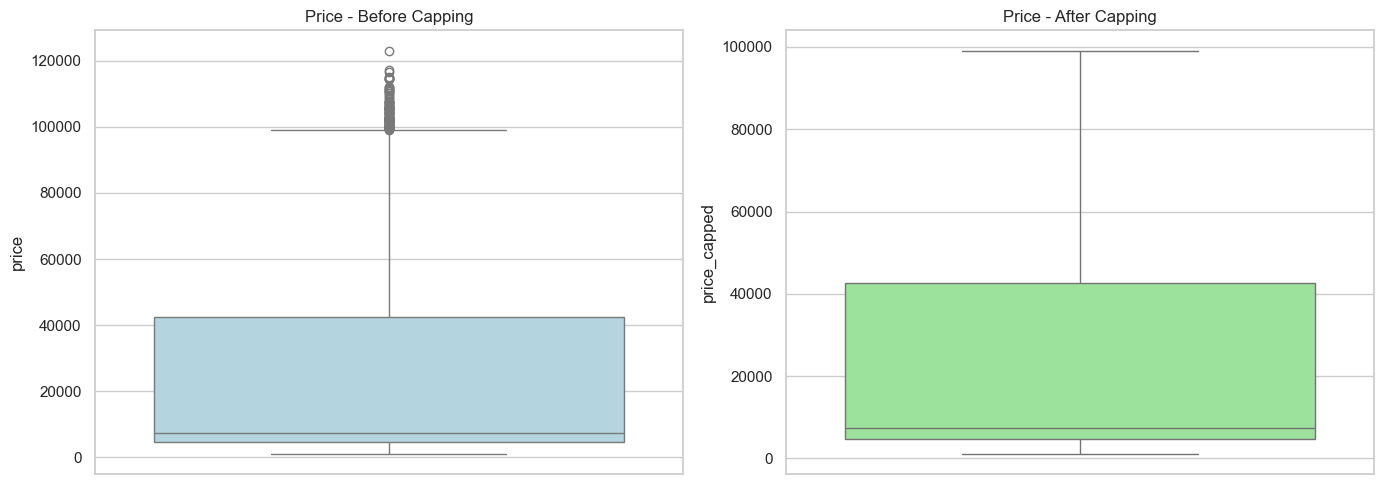

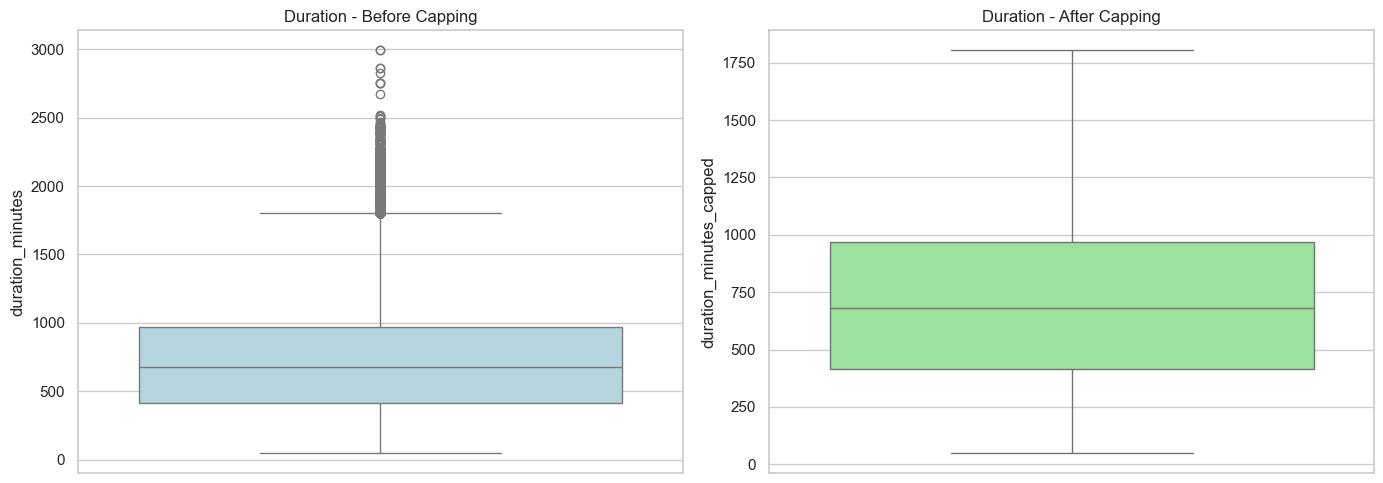

In [15]:
# 3.7 Visualise before/after capping
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=df['price'], ax=axes[0], color='lightblue')
axes[0].set_title('Price - Before Capping')
sns.boxplot(y=df['price_capped'], ax=axes[1], color='lightgreen')
axes[1].set_title('Price - After Capping')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=df['duration_minutes'], ax=axes[0], color='lightblue')
axes[0].set_title('Duration - Before Capping')
sns.boxplot(y=df['duration_minutes_capped'], ax=axes[1], color='lightgreen')
axes[1].set_title('Duration - After Capping')
plt.tight_layout()
plt.show()

In [16]:
# 3.8 Pre/post quality checkpoint
post_snapshot = {
    'rows': len(df),
    'columns': df.shape[1],
    'missing_values': int(df.isna().sum().sum()),
    'duplicate_rows': int(df.duplicated().sum())
}

pre_post_quality = pd.DataFrame([
    {'stage': 'Before preprocessing', **pre_snapshot},
    {'stage': 'After preprocessing', **post_snapshot}
])

print('Pre vs Post Data Quality:')
display(pre_post_quality)

Pre vs Post Data Quality:


,stage,rows,columns,missing_values,duplicate_rows
0,Before preprocessing,300153,11,22,0
1,After preprocessing,297936,15,0,0


In [17]:
# 4. Scenario Comparison
combined_outlier_mask = df['price_outlier_iqr'] | df['duration_minutes_outlier_iqr']
high_fare_threshold = df['price'].quantile(0.95)

scenario_a_df = df.loc[~combined_outlier_mask].copy()  # remove outlier rows
scenario_b_df = df.copy()  # keep all rows, use capped columns

scenario_comparison = pd.DataFrame([
    {
        'scenario': 'A - Remove outlier rows',
        'rows_used': len(scenario_a_df),
        'rows_removed': int(combined_outlier_mask.sum()),
        'high_fare_retained_pct': round((scenario_a_df['price'] >= high_fare_threshold).mean() * 100, 2),
        'avg_price': round(float(scenario_a_df['price'].mean()), 2),
        'bias_risk': 'Higher (premium fares under-represented)'
    },
    {
        'scenario': 'B - Cap outliers, keep rows',
        'rows_used': len(scenario_b_df),
        'rows_removed': 0,
        'high_fare_retained_pct': round((scenario_b_df['price'] >= high_fare_threshold).mean() * 100, 2),
        'avg_price': round(float(scenario_b_df['price'].mean()), 2),
        'bias_risk': 'Lower (premium segment preserved)'
    }
])

display(scenario_comparison)
print('Final choice: Scenario B (capping) — preserves population structure.')

,scenario,rows_used,rows_removed,high_fare_retained_pct,avg_price,bias_risk
0,A - Remove outlier rows,295587,2349,5.00,20969.15,Higher (premium fares under-represented)
1,"B - Cap outliers, keep rows",297936,0,5.04,20976.50,Lower (premium segment preserved)


Final choice: Scenario B (capping) — preserves population structure.


In [18]:
# 5. Feature Engineering
df_fe = df.copy()

df_fe['route'] = df_fe['source_city'] + '_to_' + df_fe['destination_city']
df_fe['duration_bucket'] = pd.cut(
    df_fe['duration_minutes'],
    bins=[-np.inf, 180, 420, 660, np.inf],
    labels=['short_<=3h', 'medium_3to7h', 'long_7to11h', 'very_long_>11h']
).astype('string')

categorical_feature_cols = [
    'airline', 'source_city', 'departure_time', 'stops',
    'arrival_time', 'destination_city', 'class', 'route', 'duration_bucket'
]
numerical_feature_cols = ['days_left', 'duration_minutes']

print(f'Route examples: {df_fe["route"].nunique()} unique routes')
print(f'Duration buckets: {df_fe["duration_bucket"].value_counts().to_dict()}')
print('\nSample:')
df_fe[['route', 'duration_minutes', 'duration_bucket']].head()

Route examples: 30 unique routes
Duration buckets: {'very_long_>11h': 153770, 'long_7to11h': 67050, 'medium_3to7h': 42970, 'short_<=3h': 34146}

Sample:


,route,duration_minutes,duration_bucket
0,delhi_to_mumbai,130.2,short_<=3h
1,delhi_to_mumbai,139.8,short_<=3h
2,delhi_to_mumbai,679.8,very_long_>11h
3,delhi_to_mumbai,135.0,short_<=3h
4,delhi_to_mumbai,139.8,short_<=3h


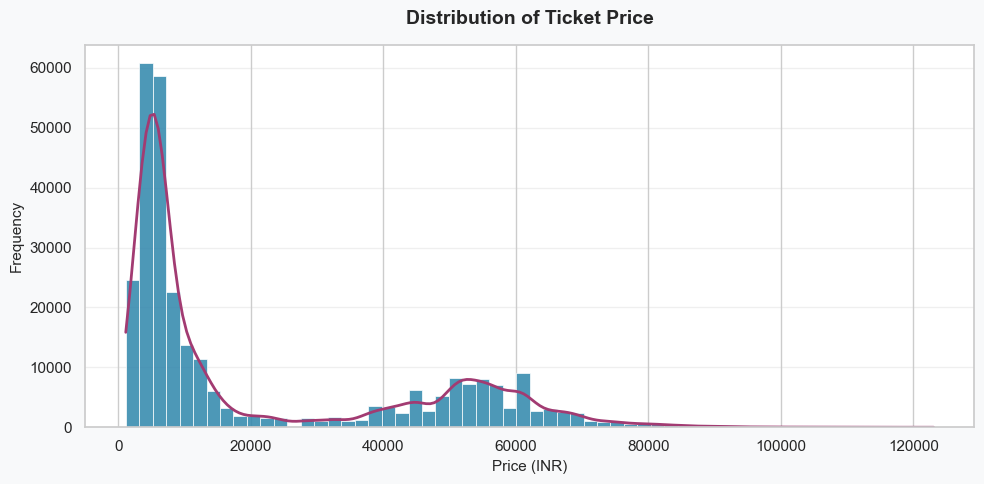

Price skewness: 1.054


In [23]:
# 6.1 Price Distribution 

# Professional colour palette
COLOUR_PRIMARY = '#2E86AB'    # Deep blue
COLOUR_SECONDARY = '#A23B72'  # Magenta
COLOUR_ACCENT = '#F18F01'     # Orange
COLOUR_BG = '#F8F9FA'         # Light grey background

plt.figure(figsize=(10, 5), facecolor=COLOUR_BG)
ax = sns.histplot(eda_df['price'], bins=60, kde=True, color=COLOUR_PRIMARY, 
                  edgecolor='white', linewidth=0.5, alpha=0.85)
ax.lines[0].set_color(COLOUR_SECONDARY)
ax.lines[0].set_linewidth(2)
plt.title('Distribution of Ticket Price', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Price (INR)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Price skewness: {eda_df["price"].skew():.3f}')

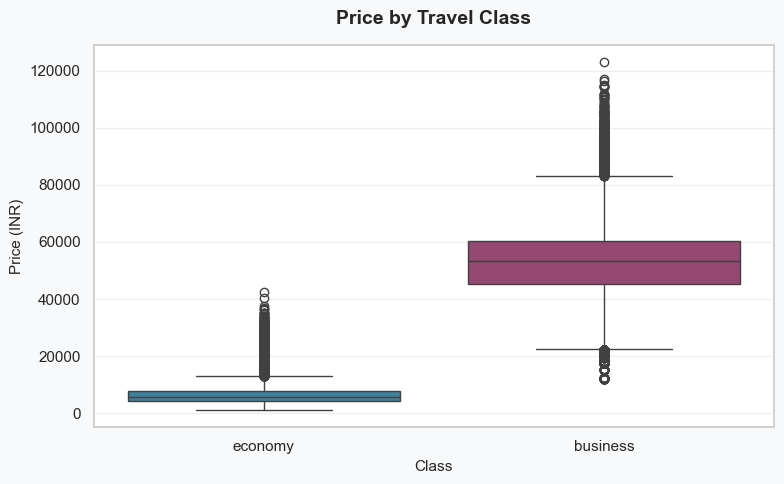

,mean,median,std
class,,,
business,52591.353311,53164.0,12944.087796
economy,6590.837085,5780.0,3749.120493


In [24]:
# 6.2 Price by Class — with appealing colours
COLOUR_ECONOMY = '#2E86AB'    # Deep blue
COLOUR_BUSINESS = '#A23B72'  # Magenta
COLOUR_BG = '#F8F9FA'

plt.figure(figsize=(8, 5), facecolor=COLOUR_BG)
sns.boxplot(data=eda_df, x='class', y='price', 
            palette={'economy': COLOUR_ECONOMY, 'business': COLOUR_BUSINESS})
plt.title('Price by Travel Class', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Class', fontsize=11)
plt.ylabel('Price (INR)', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Stats
class_stats = eda_df.groupby('class')['price'].agg(['mean', 'median', 'std'])
display(class_stats)

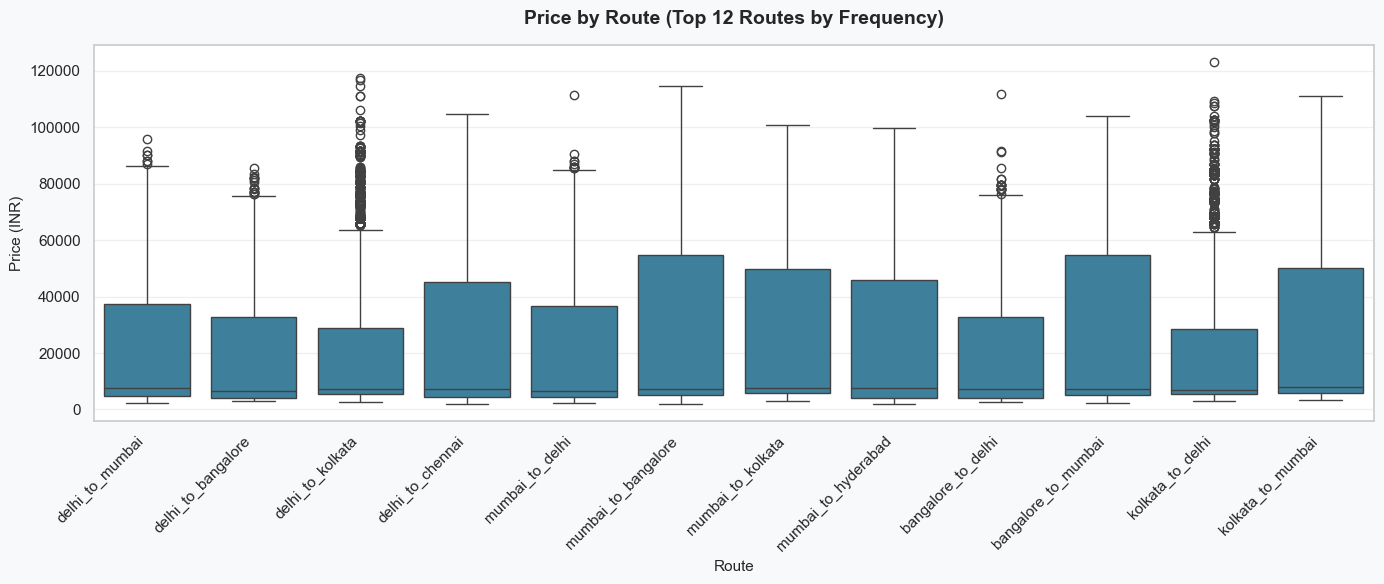

In [25]:
# 6.3 Price by Route — with appealing colours
COLOUR_PRIMARY = '#2E86AB'
COLOUR_BG = '#F8F9FA'

top_routes = eda_df['route'].value_counts().head(12).index

plt.figure(figsize=(14, 6), facecolor=COLOUR_BG)
sns.boxplot(data=eda_df[eda_df['route'].isin(top_routes)], x='route', y='price',
            color=COLOUR_PRIMARY)
plt.title('Price by Route (Top 12 Routes by Frequency)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Route', fontsize=11)
plt.ylabel('Price (INR)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

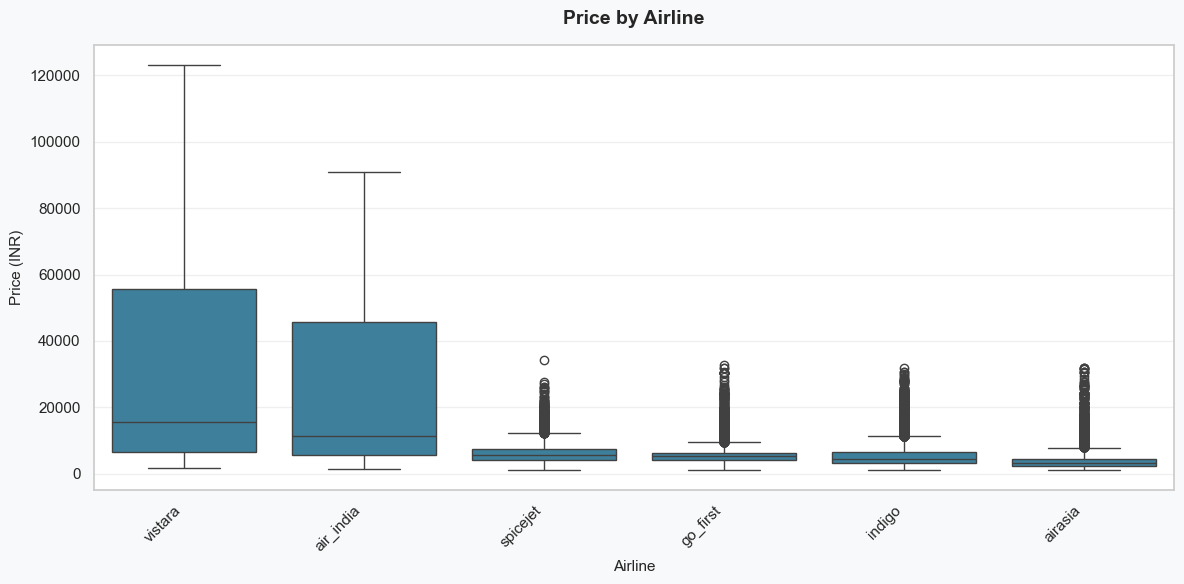

,avg_price
airline,
vistara,30494.837997
air_india,23508.171107
spicejet,6210.620542
go_first,5668.469104
indigo,5348.568132
airasia,4099.466554


In [26]:
# 6.4 Price by Airline
COLOUR_PRIMARY = '#2E86AB'
COLOUR_BG = '#F8F9FA'

plt.figure(figsize=(12, 6), facecolor=COLOUR_BG)
sns.boxplot(data=eda_df, x='airline', y='price', 
            order=eda_df.groupby('airline')['price'].median().sort_values(ascending=False).index,
            color=COLOUR_PRIMARY)
plt.title('Price by Airline', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Airline', fontsize=11)
plt.ylabel('Price (INR)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Airline averages
airline_avg = eda_df.groupby('airline')['price'].mean().sort_values(ascending=False)
display(airline_avg.to_frame('avg_price'))

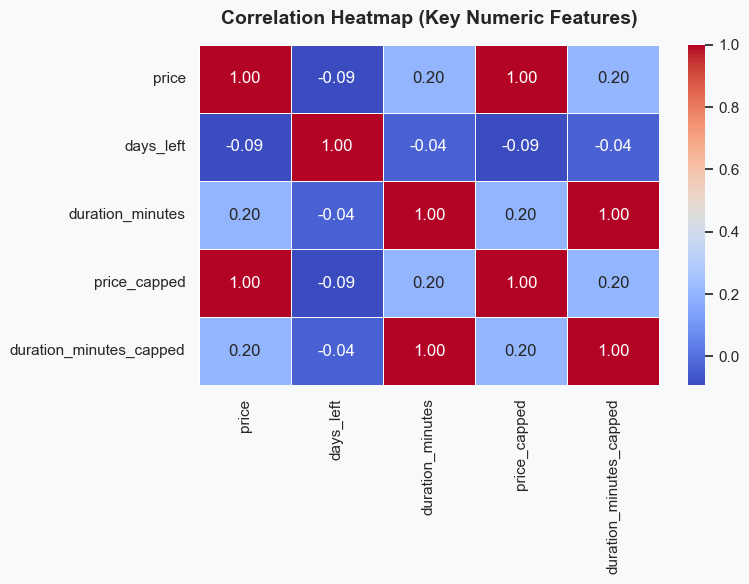

In [27]:
# 6.5 Correlation Heatmap
corr_features = ['price', 'days_left', 'duration_minutes', 'price_capped', 'duration_minutes_capped']
corr_matrix = eda_df[corr_features].corr(numeric_only=True)

plt.figure(figsize=(8, 6), facecolor=COLOUR_BG)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap (Key Numeric Features)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

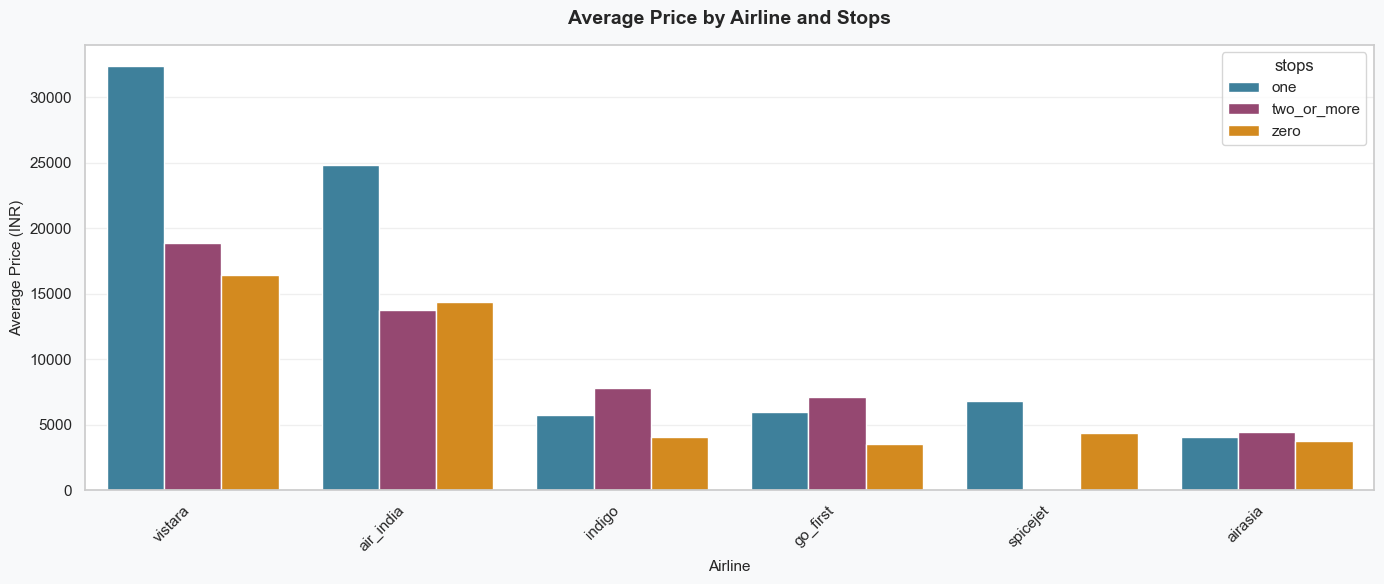

Top 10 Airline-Stops combinations:


,airline,stops,price
14,vistara,one,32388.844815
0,air_india,one,24806.576330
15,vistara,two_or_more,18850.767996
16,vistara,zero,16441.012773
2,air_india,zero,14406.297955
1,air_india,two_or_more,13771.748131
10,indigo,two_or_more,7834.838753
7,go_first,two_or_more,7107.708642
12,spicejet,one,6794.461067
6,go_first,one,5971.019834


In [29]:
# 6.6 Average Price by Airline and Stops
COLOUR_PRIMARY = '#2E86AB'
COLOUR_SECONDARY = '#A23B72'
COLOUR_ACCENT = '#F18F01'
COLOUR_BG = '#F8F9FA'

avg_price_by_airline_stops = (
    eda_df.groupby(['airline', 'stops'], as_index=False)['price']
    .mean()
    .sort_values('price', ascending=False)
)

plt.figure(figsize=(14, 6), facecolor=COLOUR_BG)
sns.barplot(data=avg_price_by_airline_stops, x='airline', y='price', hue='stops', ci=None,
            palette={'one': COLOUR_PRIMARY, 'two_or_more': COLOUR_SECONDARY, 'zero': COLOUR_ACCENT})
plt.title('Average Price by Airline and Stops', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Airline', fontsize=11)
plt.ylabel('Average Price (INR)', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Top 10 Airline-Stops combinations:')
display(avg_price_by_airline_stops.head(10))

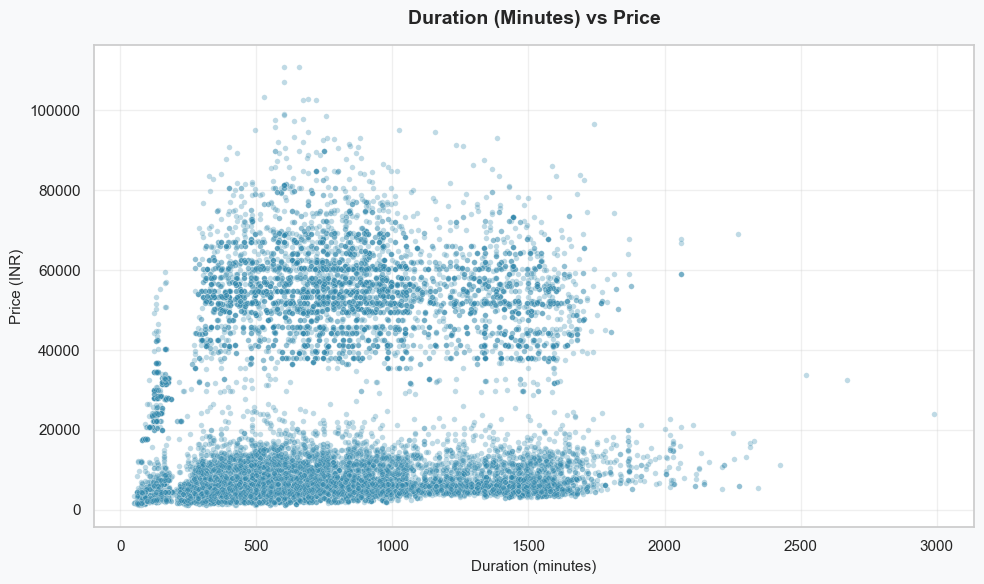

In [30]:
# 6.7 Duration vs Price
scatter_sample = eda_df.sample(n=min(20000, len(eda_df)), random_state=SEED)

plt.figure(figsize=(10, 6), facecolor=COLOUR_BG)
sns.scatterplot(data=scatter_sample, x='duration_minutes', y='price', alpha=0.3, s=16, color=COLOUR_PRIMARY)
plt.title('Duration (Minutes) vs Price', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Duration (minutes)', fontsize=11)
plt.ylabel('Price (INR)', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

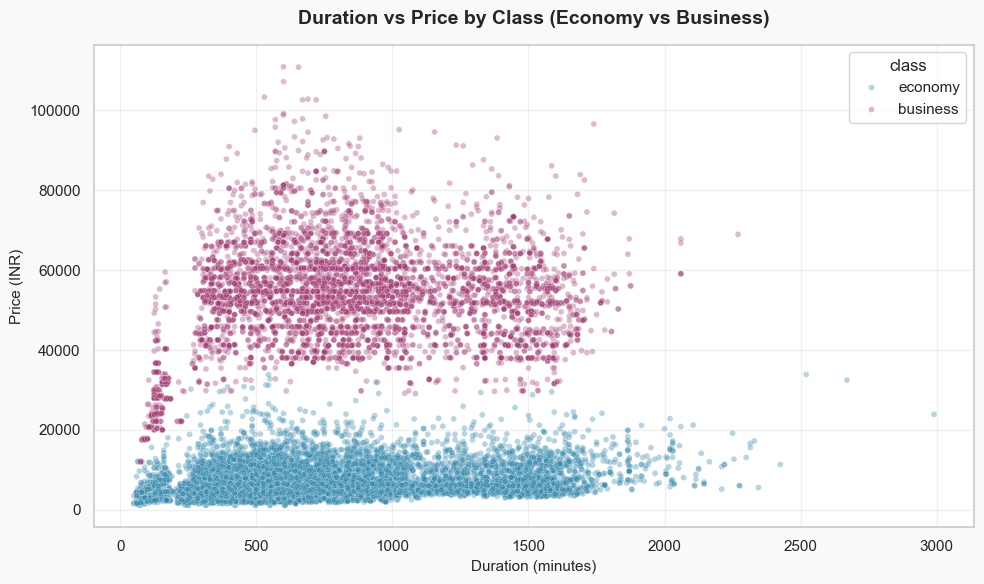

In [31]:
# 6.8 Duration vs Price by Class
COLOUR_ECONOMY = '#2E86AB'
COLOUR_BUSINESS = '#A23B72'
COLOUR_BG = '#F8F9FA'

plt.figure(figsize=(10, 6), facecolor=COLOUR_BG)
sns.scatterplot(
    data=scatter_sample[scatter_sample['class'].isin(['economy', 'business'])],
    x='duration_minutes', y='price', hue='class', alpha=0.35, s=18,
    palette={'economy': COLOUR_ECONOMY, 'business': COLOUR_BUSINESS}
)
plt.title('Duration vs Price by Class (Economy vs Business)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Duration (minutes)', fontsize=11)
plt.ylabel('Price (INR)', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
# 7. Statistical Hypothesis Testing
stats_df = df_fe.copy()

# 1. Welch t-test
economy_prices = stats_df.loc[stats_df['class'] == 'economy', 'price']
business_prices = stats_df.loc[stats_df['class'] == 'business', 'price']
t_stat, t_p = stats.ttest_ind(economy_prices, business_prices, equal_var=False)

# 2. ANOVA
airline_groups = [g['price'].values for _, g in stats_df.groupby('airline')]
f_stat, f_p = stats.f_oneway(*airline_groups)

# 3. Chi-square
contingency = pd.crosstab(stats_df['class'], stats_df['stops'])
chi2_stat, chi2_p, chi2_dof, _ = stats.chi2_contingency(contingency)

hypothesis_results = pd.DataFrame([
    {
        'test': 'Welch t-test (economy vs business)',
        'null_hypothesis': 'Mean prices are equal between economy and business classes',
        'statistic': round(t_stat, 2),
        'p_value': f'{t_p:.2e}',
        'decision': 'Reject H0' if t_p < 0.05 else 'Fail to reject H0'
    },
    {
        'test': 'ANOVA (price across airlines)',
        'null_hypothesis': 'Mean prices are equal across all airlines',
        'statistic': round(f_stat, 2),
        'p_value': f'{f_p:.2e}',
        'decision': 'Reject H0' if f_p < 0.05 else 'Fail to reject H0'
    },
    {
        'test': 'Chi-square (class vs stops)',
        'null_hypothesis': 'Class and number of stops are independent',
        'statistic': round(chi2_stat, 2),
        'p_value': f'{chi2_p:.2e}',
        'decision': 'Reject H0' if chi2_p < 0.05 else 'Fail to reject H0'
    }
])

print('Hypothesis Testing Results:')
display(hypothesis_results)
print(f'\nChi-square degrees of freedom: {chi2_dof}')
print('\nContingency Table (Class vs Stops):')
display(contingency)

Hypothesis Testing Results:


,test,null_hypothesis,statistic,p_value,decision
0,Welch t-test (economy vs business),Mean prices are equal between economy and busi...,-1064.64,0.00e+00,Reject H0
1,ANOVA (price across airlines),Mean prices are equal across all airlines,17025.54,0.00e+00,Reject H0
2,Chi-square (class vs stops),Class and number of stops are independent,5105.17,0.00e+00,Reject H0



Chi-square degrees of freedom: 2

Contingency Table (Class vs Stops):


stops,one,two_or_more,zero
class,,,
business,84249,1083,7841
economy,166060,12202,26501


In [33]:
# 8. Train/Test Split and Preprocessing Pipeline
model_df = df_fe.copy()

TRAINING_SAMPLE_SIZE = 50000
if TRAINING_SAMPLE_SIZE is not None and TRAINING_SAMPLE_SIZE < len(model_df):
    model_df = model_df.sample(TRAINING_SAMPLE_SIZE, random_state=SEED).copy()

target_col = 'price_capped'
model_feature_cols = categorical_feature_cols + numerical_feature_cols

X = model_df[model_feature_cols]
y = model_df[target_col]

# Log transform target
USE_LOG_TARGET = True
TARGET_TRANSFORM_NOTE = 'log1p(price_capped)' if USE_LOG_TARGET else 'none'

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED
)

if USE_LOG_TARGET:
    y_train_model = np.log1p(y_train)
    y_test_model = np.log1p(y_test)
else:
    y_train_model = y_train.copy()
    y_test_model = y_test.copy()

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numerical_feature_cols),
    ('cat', categorical_pipeline, categorical_feature_cols)
])

X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)
print('Target:', target_col)
print('Prepared matrix shape (train):', X_train_prepared.shape)
print('Target transform for training:', TARGET_TRANSFORM_NOTE)

Train shape: (35000, 11) | Test shape: (15000, 11)
Target: price_capped
Prepared matrix shape (train): (35000, 71)
Target transform for training: log1p(price_capped)


In [34]:
# 9.1 Model Training
rf_n_estimators = 30

model_specs = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=SEED),
    'Lasso Regression': Lasso(alpha=0.1, max_iter=1500, tol=5e-3, selection='random', random_state=SEED),
    'Decision Tree': DecisionTreeRegressor(random_state=SEED, max_depth=20, min_samples_leaf=5),
    'Random Forest': RandomForestRegressor(
        random_state=SEED, n_estimators=rf_n_estimators,
        max_depth=None, min_samples_leaf=2, n_jobs=-1
    )
}

trained_models = {}
for name, estimator in model_specs.items():
    estimator.fit(X_train_prepared, y_train_model)
    trained_models[name] = estimator
    print(f'Trained: {name}')

Trained: Linear Regression
Trained: Ridge Regression
Trained: Lasso Regression
Trained: Decision Tree
Trained: Random Forest


In [35]:
# 9.2 Model Evaluation
evaluation_rows = []
predictions = {}

for model_name, estimator in trained_models.items():
    y_pred_model = estimator.predict(X_test_prepared)
    y_pred = np.expm1(y_pred_model) if USE_LOG_TARGET else y_pred_model
    predictions[model_name] = y_pred
    
    evaluation_rows.append({
        'model': model_name,
        'r2': round(r2_score(y_test, y_pred), 4),
        'rmse': round(np.sqrt(mean_squared_error(y_test, y_pred)), 2),
        'mae': round(mean_absolute_error(y_test, y_pred), 2),
        'mape': round(mean_absolute_percentage_error(y_test, y_pred), 4)
    })

evaluation_df = pd.DataFrame(evaluation_rows).sort_values('r2', ascending=False)
print('Model Comparison Results:')
display(evaluation_df)

Model Comparison Results:


,model,r2,rmse,mae,mape
4,Random Forest,0.9783,3378.30,1645.90,0.1056
3,Decision Tree,0.9681,4094.36,2109.96,0.1341
0,Linear Regression,0.8836,7817.86,4621.47,0.2595
1,Ridge Regression,0.8836,7817.38,4621.28,0.2595
2,Lasso Regression,0.7346,11805.04,7102.17,0.4208


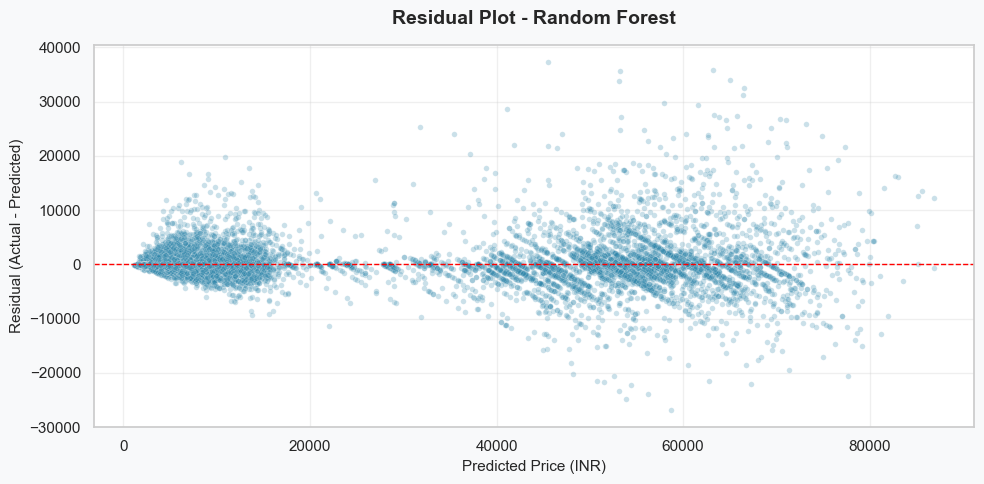

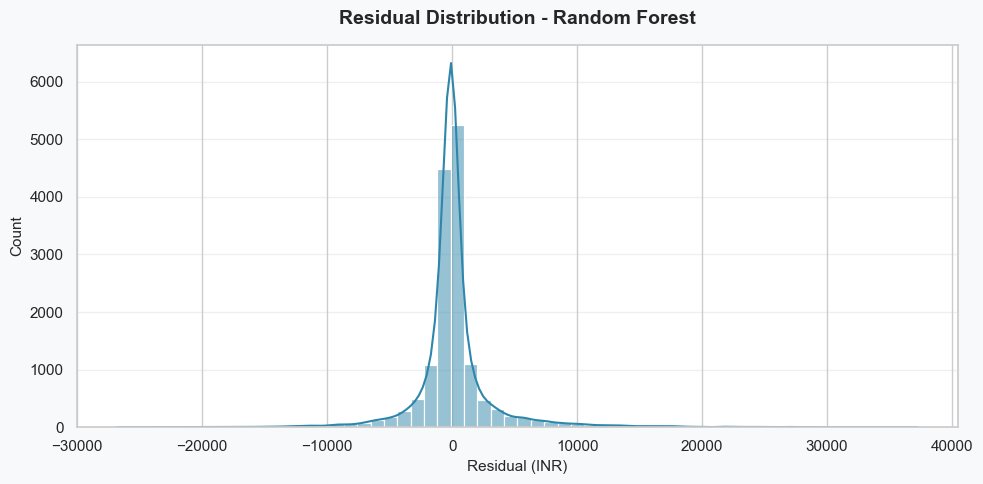

Best model: Random Forest
Mean residual: 163.90
Std residual: 3374.43


In [39]:
# 9.3 Residual Diagnostics
best_model_name = evaluation_df.iloc[0]['model']
best_model = trained_models[best_model_name]
best_pred = predictions[best_model_name]
residuals = y_test - best_pred

# Residual scatter plot
plt.figure(figsize=(10, 5), facecolor=COLOUR_BG)
sns.scatterplot(x=best_pred, y=residuals, alpha=0.25, s=16, color=COLOUR_PRIMARY)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title(f'Residual Plot - {best_model_name}', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Price (INR)', fontsize=11)
plt.ylabel('Residual (Actual - Predicted)', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Residual distribution
plt.figure(figsize=(10, 5), facecolor=COLOUR_BG)
sns.histplot(residuals, bins=60, kde=True, color=COLOUR_PRIMARY)
plt.title(f'Residual Distribution - {best_model_name}', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Residual (INR)', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Best model: {best_model_name}')
print(f'Mean residual: {residuals.mean():.2f}')
print(f'Std residual: {residuals.std():.2f}')

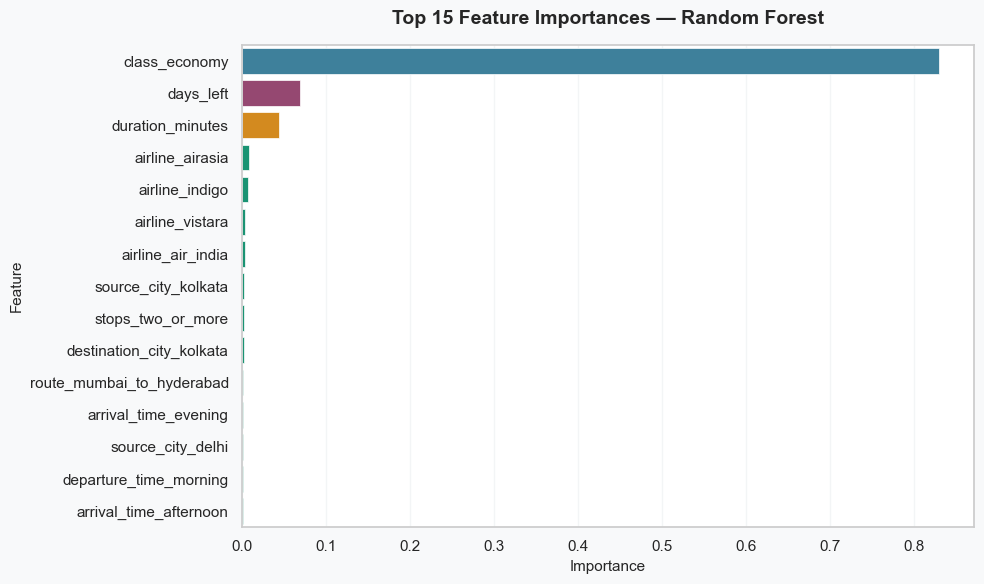

Top 15 Feature Importances:


,feature,importance
36,class_economy,0.829901
0,days_left,0.069633
1,duration_minutes,0.043993
3,airline_airasia,0.008876
5,airline_indigo,0.006983
7,airline_vistara,0.003848
2,airline_air_india,0.003739
12,source_city_kolkata,0.002321
21,stops_two_or_more,0.002178
33,destination_city_kolkata,0.001917


In [47]:
# 9.4 Feature Importance 
COLOUR_SECONDARY = '#A23B72'
COLOUR_ACCENT = '#F18F01'
COLOUR_SUCCESS = '#06A77D'
COLOUR_BG = '#F8F9FA'
COLOUR_GRID = '#E9ECEF'

cat_ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_ohe.get_feature_names_out(categorical_feature_cols)
all_feature_names = list(numerical_feature_cols) + list(cat_feature_names)

feature_importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

# Create gradient colours based on importance
colours = []
for i, imp in enumerate(feature_importance_df['importance']):
    if imp > 0.5:
        colours.append(COLOUR_PRIMARY)
    elif imp > 0.05:
        colours.append(COLOUR_SECONDARY)
    elif imp > 0.01:
        colours.append(COLOUR_ACCENT)
    else:
        colours.append(COLOUR_SUCCESS)

plt.figure(figsize=(10, 6), facecolor=COLOUR_BG)
sns.barplot(data=feature_importance_df, y='feature', x='importance', 
            palette=colours, edgecolor='white', linewidth=0.5)
plt.title('Top 15 Feature Importances — Random Forest', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.grid(axis='x', color=COLOUR_GRID, alpha=0.5)
plt.tight_layout()
plt.show()

print('Top 15 Feature Importances:')
display(feature_importance_df)

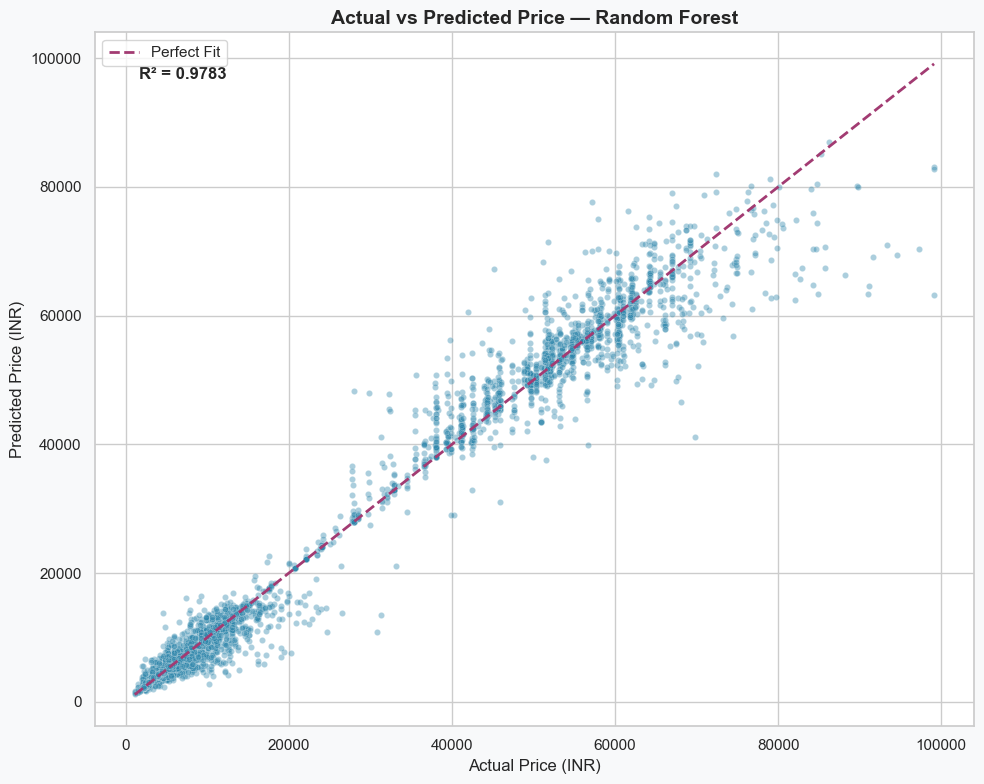

In [45]:
# Actual vs Predicted — Random Forest
plt.figure(figsize=(10, 8), facecolor=COLOUR_BG)

# Sample for cleaner plot
sample_size = min(5000, len(y_test))
sample_idx = np.random.choice(len(y_test), size=sample_size, replace=False)
y_test_sample = y_test.iloc[sample_idx]
best_pred_sample = best_pred[sample_idx]

# Scatter plot
plt.scatter(y_test_sample, best_pred_sample, alpha=0.4, s=20, 
            color=COLOUR_PRIMARY, edgecolor='white', linewidth=0.3)

# Perfect fit line
min_val = min(y_test_sample.min(), best_pred_sample.min())
max_val = max(y_test_sample.max(), best_pred_sample.max())
plt.plot([min_val, max_val], [min_val, max_val], 
         color=COLOUR_SECONDARY, linestyle='--', linewidth=2, label='Perfect Fit')

# R² annotation
r2 = r2_score(y_test, best_pred)
plt.text(0.05, 0.95, f'R² = {r2:.4f}', transform=plt.gca().transAxes,
         fontsize=12, fontweight='bold', verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.title('Actual vs Predicted Price — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Actual Price (INR)')
plt.ylabel('Predicted Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
# 10. Key Insights
insight_df = df_fe.copy()

price_by_class = insight_df.groupby('class', as_index=False)['price'].agg(['mean', 'median', 'count']).reset_index()
price_by_airline = insight_df.groupby('airline', as_index=False)['price'].mean().sort_values('price', ascending=False)
days_left_price_corr = insight_df[['days_left', 'price']].corr().loc['days_left', 'price']

business_avg = insight_df.loc[insight_df['class'] == 'business', 'price'].mean()
economy_avg = insight_df.loc[insight_df['class'] == 'economy', 'price'].mean()
class_premium_pct = ((business_avg - economy_avg) / economy_avg) * 100

summary_points = pd.DataFrame([
    {
        'question': 'Why is business class more expensive?',
        'evidence': f'Business mean price is {class_premium_pct:.2f}% above economy.'
    },
    {
        'question': 'Do fewer days to departure increase price?',
        'evidence': f'Correlation(days_left, price) = {days_left_price_corr:.3f} (negative supports late-booking premium).'
    },
    {
        'question': 'Which airlines tend to be highest priced?',
        'evidence': 'Top average-price airlines shown below.'
    },
    {
        'question': 'Which variables increase/decrease ticket price?',
        'evidence': 'See feature importance table and EDA patterns.'
    }
])

print('=== KEY INSIGHTS ===')
display(summary_points)
print('\nTop 5 airlines by average price:')
display(price_by_airline.head())
print('\nPrice by class:')
display(price_by_class)

=== KEY INSIGHTS ===


,question,evidence
0,Why is business class more expensive?,Business mean price is 697.95% above economy.
1,Do fewer days to departure increase price?,"Correlation(days_left, price) = -0.092 (negati..."
2,Which airlines tend to be highest priced?,Top average-price airlines shown below.
3,Which variables increase/decrease ticket price?,See feature importance table and EDA patterns.



Top 5 airlines by average price:


,airline,price
5,vistara,30494.837997
0,air_india,23508.171107
4,spicejet,6210.620542
2,go_first,5668.469104
3,indigo,5348.568132



Price by class:


,index,class,mean,median,count
0,0,business,52591.353311,53164.0,93173
1,1,economy,6590.837085,5780.0,204763
